# **Introduction**
Seismic traces are the convolution of the Earth's reflectivity with a seismic wavelet, in addition with noise.
By applying deconvolution, the project aims to recover the reflectivity by removing the wavelet's imprint.
This notebook demonstratres:

*   Generation of synthetic seismic data.

*   Convolution of seismic data with reflectivity.




*   Applying Wiener deconvolution in frequency domain (Fourier transformation) to provide stable, regularized estimate of reflectivity.




In [1461]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [1462]:
#   Generating synthetic reflectivity series.
reflectivity = np.zeros(500)
reflectivity[[50, 120, 123, 200, 300, 400,]] = [0.8, -0.6,-0.4, 0.7, -0.5, 0.9]

In [1463]:
#   Ricker Wavelet- zero-phase wavelet

f = 25    #frequency
length = 0.2
dt = 0.002  #time step

t_wavelet = np.arange(0, length, dt)
pi2 = (np.pi**2) * (f**2)
wavelet = (1 - 2*pi2*t_wavelet**2) * np.exp(-pi2*t_wavelet**2)


In [1464]:
#  Convolution of reflectivity with wavelet
synthetic_trace = np.convolve(reflectivity, wavelet)

In [1465]:
#  Adding randomly generated noise
noise = np.random.normal(0, 0.05, synthetic_trace.shape)
synthetic_trace_noisy = synthetic_trace + noise

In [1466]:
#  Wiener Deconvolution
def wiener_deconvolution(trace, wavelet, alpha):
    n = len(trace)
    nfft = 2*n

    # Fourier transformation to switch to Frequency domain
    S = np.fft.fft(trace, nfft)
    W = np.fft.fft(wavelet, nfft)

    # Wiener filter
    W_conj = np.conj(W)
    R = (S * W_conj) / (W * W_conj + alpha)

    # Switching back to time domain
    r_estimated = np.fft.ifft(R)
    return np.real(r_estimated[:n])



signal_variation = np.var(synthetic_trace)
noise_variation = np.var(noise)
alpha = noise_variation / (signal_variation)

wiener_trace = wiener_deconvolution(synthetic_trace_noisy, wavelet, alpha)


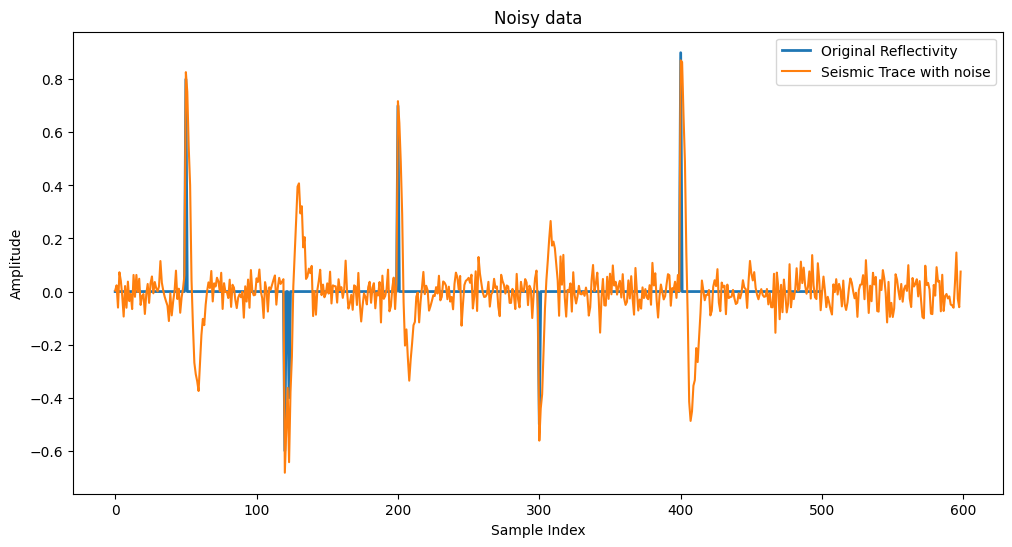

In [1467]:
from re import A
#  Plotting the results
plt.figure(figsize=(12,6))
plt.plot(reflectivity, label='Original Reflectivity', linewidth=2)
plt.plot(synthetic_trace_noisy,label= "Seismic Trace with noise")
plt.title('Noisy data')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


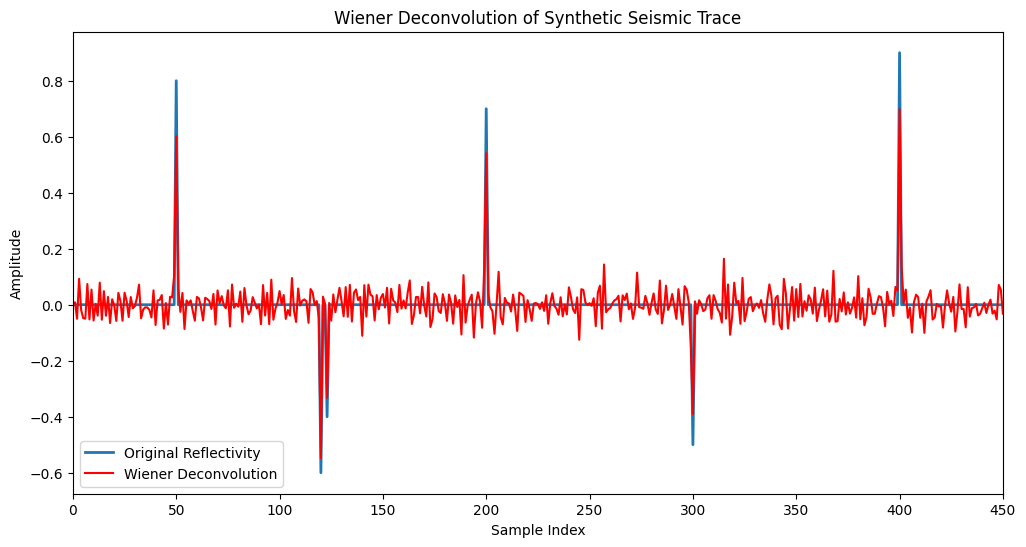

In [1468]:
#  Plotting the results
plt.figure(figsize=(12,6))
plt.plot(reflectivity, label='Original Reflectivity', linewidth=2)
plt.plot(wiener_trace, label='Wiener Deconvolution', color="red")
plt.title('Wiener Deconvolution of Synthetic Seismic Trace')
plt.xlabel('Sample Index')
plt.xlim(0,450)
plt.ylabel('Amplitude')
plt.legend()
plt.show()

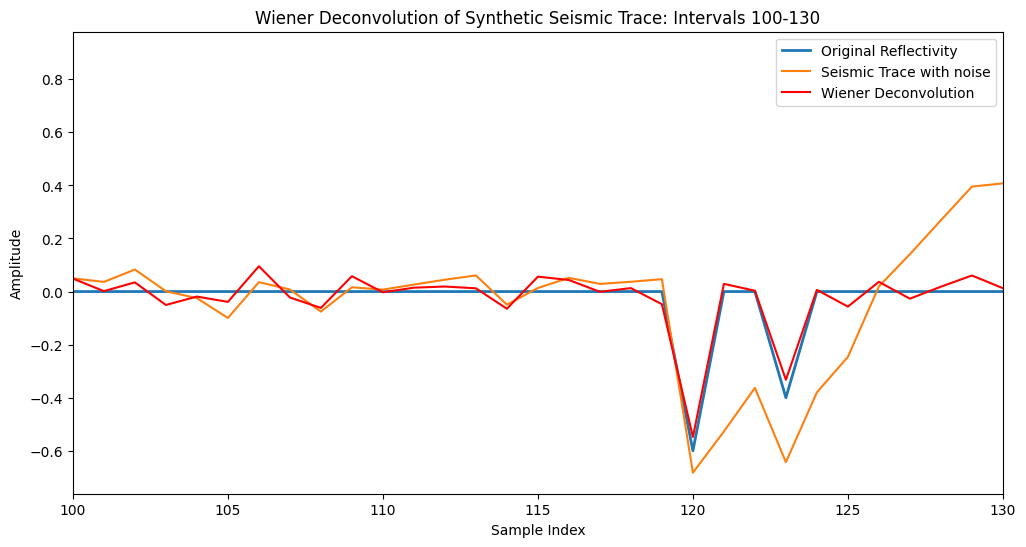

In [1469]:
#  Zoomed to close boundaries
plt.figure(figsize=(12,6))
plt.plot(reflectivity, label='Original Reflectivity', linewidth=2)
plt.plot(synthetic_trace_noisy,label= "Seismic Trace with noise")
plt.plot(wiener_trace, label='Wiener Deconvolution', color="red")
plt.title('Wiener Deconvolution of Synthetic Seismic Trace: Intervals 100-130')
plt.xlabel('Sample Index')
plt.xlim(100,130)
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [1470]:
peaks_idx, properties= find_peaks(np.abs(wiener_trace), height=0.25)
estimated_amplitudes = wiener_trace[peaks_idx]
recovery_rates = (estimated_amplitudes / reflectivity[[50, 120, 123, 200, 300, 400,]]) * 100
print("Recovery rates:" )
print(recovery_rates)
print(f"Average recovery rate: {sum(recovery_rates)/len(recovery_rates)}")

Recovery rates:
[75.24154368 91.32226771 83.11366466 77.30263633 78.13530461 77.61743019]
Average recovery rate: 80.45547453131032


**Conclusion**

The deconvolved trace recovers the spike-like events that correspond to true reflectivity, while filtering noise.
Furthermore, when two reflectivity spikes were placed very close to each other (here 120 and 123), the noisy seismic trace showed strong interference due to wavelet overlap. After applying Wiener deconvolution, the energy became more concentrated around the reflector positions, allowing two closely spaced layers to appear more distinguishable. Across multiple tests with varying noise, algoritm achieved more than 75% recovery rate.

# **References**



*   Yilmaz, Ö. (2001). Seismic Data Analysis: Processing, Inversion, and Interpretation of Seismic Data. Society of Exploration Geophysicists. (Primary source for Wiener Deconvolution theory)

*   Shearer, P. M. (2009). Introduction to Seismology. Cambridge University Press. (Physics of Convolution)


*   Stein, S., & Wysession, M. (2003). An Introduction to Seismology, Earthquakes, and Earth Structure.




